In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

### Load MNIST Dataset

In [2]:
df = keras.datasets.mnist.load_data()
(x_train, y_train), (x_test, y_test) = df
print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [3]:
data_train = pd.read_csv(r"mnist_train.csv")
data_test = pd.read_csv(r"mnist_test.csv")
print(data_train.shape, data_test.shape)

(60000, 785) (10000, 785)


In [4]:
data_train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
y_train = data_train["label"].values
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,))

In [6]:
type(y_train)

numpy.ndarray

In [7]:
x_train = data_train.drop("label", axis=1).values
x_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784))

In [8]:
y_test = data_test["label"].values
x_test = data_test.drop("label", axis=1).values

print(x_test.shape, y_test.shape)

(10000, 784) (10000,)


**Normalizing X_train and X_test data**

In [9]:
x_train = x_train.astype("float") / 255
x_test = x_test.astype("float") / 255
type(x_train)

numpy.ndarray

### Neural Network

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [11]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

c:\Ayush\mca\Deep Learning\dl-sheryians\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Compiling the Sequential Model**

In [12]:
# one hot encoding
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [13]:
x_train_img = x_train.reshape(-1, 28, 28)
x_test_img = x_test.reshape(-1, 28, 28)

In [14]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

### Training the Model

In [15]:
history_ann = model.fit(x_train_img, y_train_cat, epochs=10, batch_size=32, validation_data=(x_test_img, y_test_cat), verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9280 - loss: 0.2432 - val_accuracy: 0.9642 - val_loss: 0.1212
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9675 - loss: 0.1043 - val_accuracy: 0.9716 - val_loss: 0.0907
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9772 - loss: 0.0734 - val_accuracy: 0.9724 - val_loss: 0.0856
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9825 - loss: 0.0540 - val_accuracy: 0.9777 - val_loss: 0.0733
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9863 - loss: 0.0429 - val_accuracy: 0.9756 - val_loss: 0.0794
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9887 - loss: 0.0345 - val_accuracy: 0.9744 - val_loss: 0.0891
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9906 - loss: 0.0294 - val_accuracy: 0.9761 - val_loss: 0.0909
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9919 - loss: 0.0240 - 

In [18]:
acc_ann = model.evaluate(x_test_img, y_test_cat, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9764 - loss: 0.0945


In [19]:
acc_ann

[0.09445168823003769, 0.9764000177383423]

In [20]:
print(f"Accuracy : {acc_ann[1]}\nLoss : {acc_ann[0]}")

Accuracy : 0.9764000177383423
Loss : 0.09445168823003769


**Modifying Learning Rates**

In [22]:
from tensorflow.keras.optimizers import Adam

In [23]:
custom_adam1 = Adam(learning_rate=0.01)
custom_adam2 = Adam(learning_rate=0.001)
custom_adam3 = Adam(learning_rate=0.0001)

> Learning Rate : 0.01, Batch Size : 32

In [24]:
model.compile(optimizer=custom_adam1, loss="categorical_crossentropy", metrics=["accuracy"])

In [25]:
model.fit(x_train_img, y_train_cat, epochs=10, batch_size=32, verbose=1, validation_data=(x_test_img, y_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9431 - loss: 0.2056 - val_accuracy: 0.9479 - val_loss: 0.2059
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9568 - loss: 0.1611 - val_accuracy: 0.9522 - val_loss: 0.1933
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9600 - loss: 0.1518 - val_accuracy: 0.9606 - val_loss: 0.1905
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9649 - loss: 0.1365 - val_accuracy: 0.9599 - val_loss: 0.1768
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9688 - loss: 0.1254 - val_accuracy: 0.9617 - val_loss: 0.1771
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9712 - loss: 0.1178 - val_accuracy: 0.9653 - val_loss: 0.1947
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9729 - loss: 0.1119 - val_accuracy: 0.9590 - val_loss: 0.2151
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9743 - loss: 0.1073 - 

In [26]:
model1_data = model.evaluate(x_test_img, y_test_cat, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9685 - loss: 0.1820  


In [27]:
print("Learning Rate : 0.01, Batch Size : 32, Accuracy gone : ")
print(model1_data[1])

Learning Rate : 0.01, Batch Size : 32, Accuracy gone : 
0.968500018119812


In [28]:
# Train Model for Learning Rate : 0.001, Batch Size : 64
model.compile(optimizer=custom_adam2, loss="categorical_crossentropy", metrics=["accuracy"])

In [29]:
model.fit(x_train_img, y_train_cat, epochs=10,batch_size=64, validation_data=(x_test_img, y_test_cat), verbose=1)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9872 - loss: 0.0485 - val_accuracy: 0.9761 - val_loss: 0.1373
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9909 - loss: 0.0316 - val_accuracy: 0.9769 - val_loss: 0.1333
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9924 - loss: 0.0255 - val_accuracy: 0.9774 - val_loss: 0.1350
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9935 - loss: 0.0212 - val_accuracy: 0.9783 - val_loss: 0.1415
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9941 - loss: 0.0186 - val_accuracy: 0.9783 - val_loss: 0.1425
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9948 - loss: 0.0164 - val_accuracy: 0.9791 - val_loss: 0.1531
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9952 - loss: 0.0146 - val_accuracy: 0.9797 - val_loss: 0.1523
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9955 - loss: 0.0136 - val_accuracy: 0.

In [30]:
acc_ann64 = model.evaluate(x_test_img, y_test_cat, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.9794 - loss: 0.1803


In [31]:
print("For Learning Rate : 0.001, Batch Size : 64, Accuracy is")
print(acc_ann64[1])

For Learning Rate : 0.001, Batch Size : 64, Accuracy is
0.9793999791145325


> Other two learning rates can be done in similar ways

## Visualizing our Model Performance

In [33]:
import matplotlib.pyplot as plt

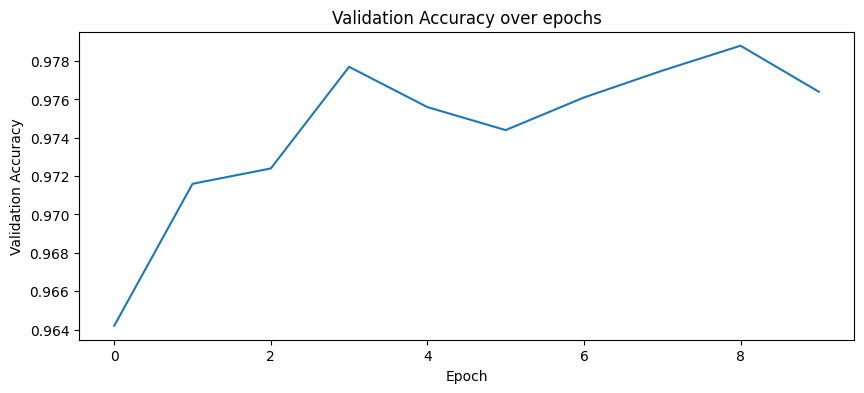

In [36]:
plt.figure(figsize=(10,4))
plt.plot(history_ann.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy over epochs")
plt.show()

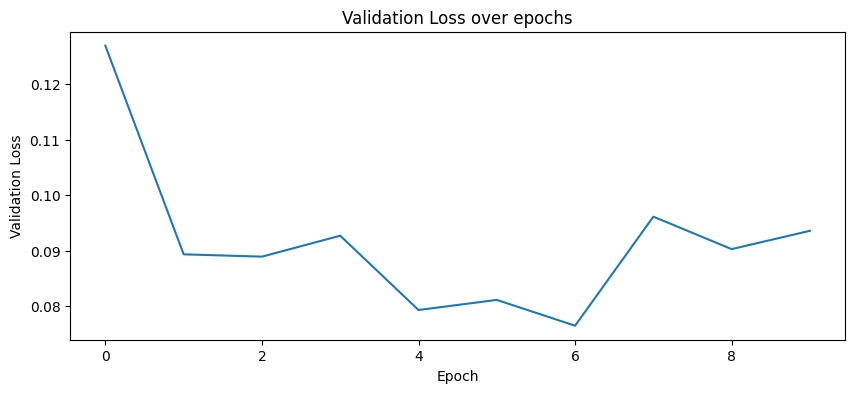

In [61]:
plt.figure(figsize=(10,4))
plt.plot(history_ann.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss over epochs")
plt.show()

In [38]:
def predict(xImg) :
    pred = model.predict(xImg.reshape(1,28,28,1))
    return pred.argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


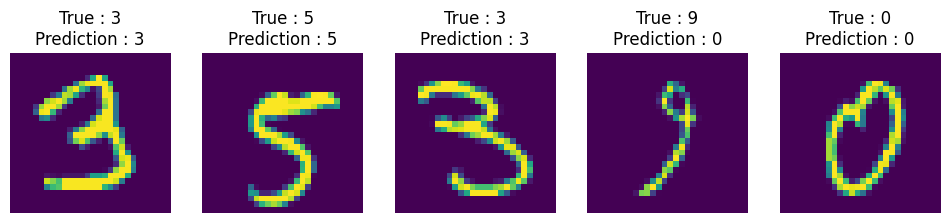

In [41]:
plt.figure(figsize=(12,6))
for i in range(5) :
    idx = np.random.randint(len(x_test_img))
    prediction = predict(x_test_img[idx])
    true = y_test[idx]
    plt.subplot(1, 5, i+1)
    plt.axis("off")
    label = "True : " + str(true) + "\n"
    label += "Prediction : " + str(prediction)
    plt.title(label)
    plt.imshow(x_test_img[idx])